# Netflix Subscriptions Forecasting

In this project, we will use Python to forecast Netflix subscriber growth using time series analysis to help drive data-driven strategies for financial planning, content creation, and operational efficiency.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTQFo8vtEwsMPVjm28sqds7a5aYPKdnrDZxsqqsHlY5Hw&s=10' width='750'>

In [3]:
#Librarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio
from statsmodels.tsa.arima.model import ARIMA

### EDA 

In [4]:
df=pd.read_csv('Netflix-Subscriptions.csv')

In [5]:
df.head()

,Time Period,Subscribers
0,01/04/2013,34240000
1,01/07/2013,35640000
2,01/10/2013,38010000
3,01/01/2014,41430000
4,01/04/2014,46130000


In [6]:
df.tail()

,Time Period,Subscribers
37,01/07/2022,220670000
38,01/10/2022,223090000
39,01/01/2023,230750000
40,01/04/2023,232500000
41,01/07/2023,238390000


In [7]:
df.shape

(42, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time Period  42 non-null     object
 1   Subscribers  42 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 804.0+ bytes


In [9]:
df.isnull().sum()

Time Period    0
Subscribers    0
dtype: int64

In [10]:
df['Time Period'].value_counts()

Time Period
01/04/2013    1
01/01/2021    1
01/01/2019    1
01/04/2019    1
01/07/2019    1
01/10/2019    1
01/01/2020    1
01/04/2020    1
01/07/2020    1
01/10/2020    1
01/04/2021    1
01/07/2013    1
01/07/2021    1
01/10/2021    1
01/01/2022    1
01/04/2022    1
01/07/2022    1
01/10/2022    1
01/01/2023    1
01/04/2023    1
01/10/2018    1
01/07/2018    1
01/04/2018    1
01/01/2018    1
01/10/2013    1
01/01/2014    1
01/04/2014    1
01/07/2014    1
01/10/2014    1
01/01/2015    1
01/04/2015    1
01/07/2015    1
01/10/2015    1
01/01/2016    1
01/04/2016    1
01/07/2016    1
01/10/2016    1
01/01/2017    1
01/04/2017    1
01/07/2017    1
01/10/2017    1
01/07/2023    1
Name: count, dtype: int64

In [11]:
df.describe()

,Subscribers
count,4.200000e+01
mean,1.304243e+08
std,6.891896e+07
min,3.424000e+07
25%,6.722500e+07
50%,1.216250e+08
75%,2.015325e+08
max,2.383900e+08


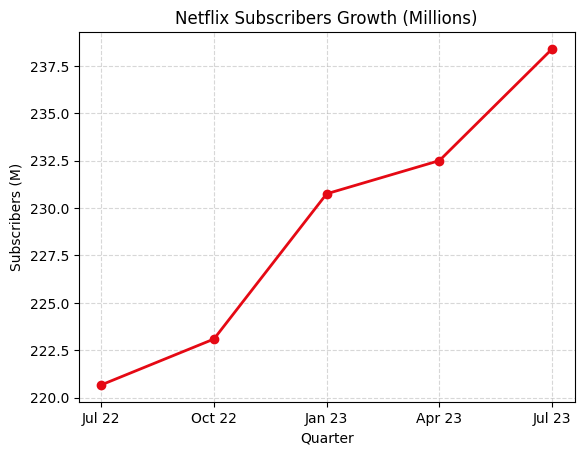

In [17]:
import matplotlib.pyplot as plt

# Data
dates = ['Jul 22', 'Oct 22', 'Jan 23', 'Apr 23', 'Jul 23']
subscribers = [220.67, 223.09, 230.75, 232.50, 238.39]

# Plot
plt.plot(dates, subscribers, marker='o', color='#E50914', linewidth=2)
plt.title('Netflix Subscribers Growth (Millions)')
plt.xlabel('Quarter')
plt.ylabel('Subscribers (M)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [20]:
df['Time Period'] = pd.to_datetime(df['Time Period'], format='%d/%m/%Y')

In [21]:
df.head()

,Time Period,Subscribers
0,2013-04-01,34240000
1,2013-07-01,35640000
2,2013-10-01,38010000
3,2014-01-01,41430000
4,2014-04-01,46130000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Time Period  42 non-null     datetime64[ns]
 1   Subscribers  42 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 804.0 bytes


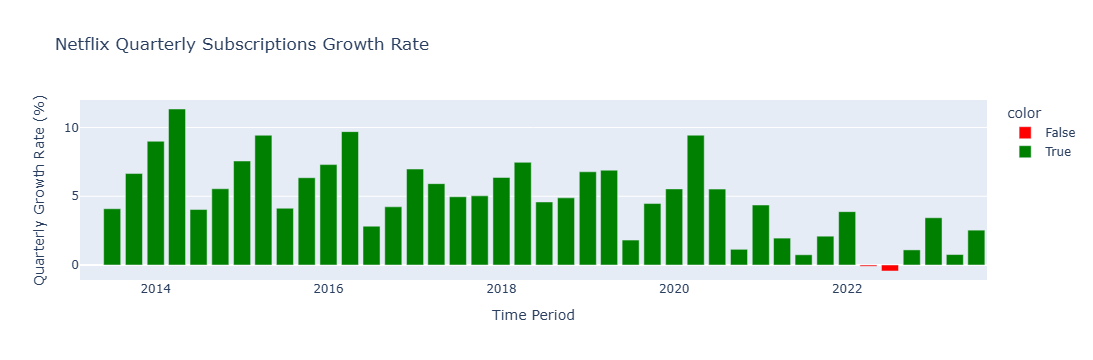

In [27]:
import plotly.express as px

# Calculate growth rate
df['Quarterly Growth Rate'] = df['Subscribers'].pct_change() * 100

# Plot bar chart
fig = px.bar(
    df, 
    x='Time Period', 
    y='Quarterly Growth Rate',
    color=df['Quarterly Growth Rate'] > 0,
    color_discrete_map={True: 'green', False: 'red'},
    title='Netflix Quarterly Subscriptions Growth Rate',
    labels={'Quarterly Growth Rate': 'Quarterly Growth Rate (%)'}
)
fig.show()

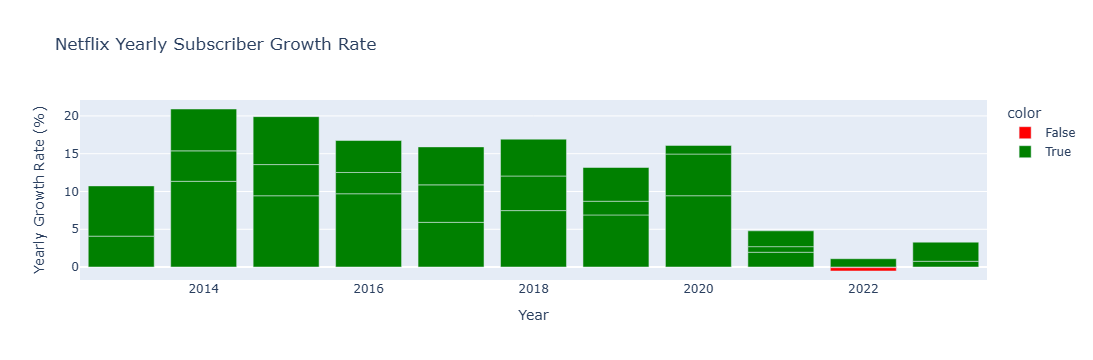

In [28]:
import plotly.express as px

# Calculate yearly growth rate
df['Year'] = df['Time Period'].dt.year
df['Yearly Growth'] = df.groupby('Year')['Subscribers'].pct_change().fillna(0) * 100

# Plot bar chart
fig = px.bar(
    df, 
    x='Year', 
    y='Yearly Growth',
    color=df['Yearly Growth'] > 0,
    color_discrete_map={True: 'green', False: 'red'},
    title='Netflix Yearly Subscriber Growth Rate',
    labels={'Yearly Growth': 'Yearly Growth Rate (%)'}
)
fig.show()

In [30]:
time_series = df.set_index('Time Period')['Subscribers']

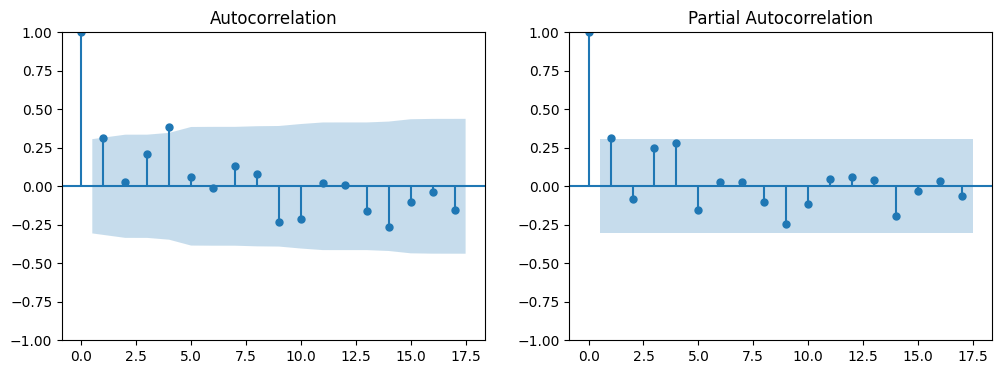

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
differenced_series = time_series.diff().dropna()

# Plot ACF and PACF of differenced time series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series, ax=axes[0])
plot_pacf(differenced_series, ax=axes[1])
plt.show()

### Modeling

In [33]:
p, d, q = 1, 1, 1
model = ARIMA(time_series, order=(p, d, q))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:            Subscribers   No. Observations:                   42
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -672.993
Date:                Thu, 17 Sep 2026   AIC                           1351.986
Time:                        10:19:52   BIC                           1357.127
Sample:                    04-01-2013   HQIC                          1353.858
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997      0.012     80.764      0.000       0.975       1.024
ma.L1         -0.9908      0.221     -4.476      0.000      -1.425      -0.557
sigma2      1.187e+13   1.57e-14   7.57e+26      0.0

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-OCT will be used.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-OCT will be used.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-OCT will be used.



In [34]:
future_steps = 5
predictions = results.predict(len(time_series), len(time_series) + future_steps - 1)
predictions = predictions.astype(int)

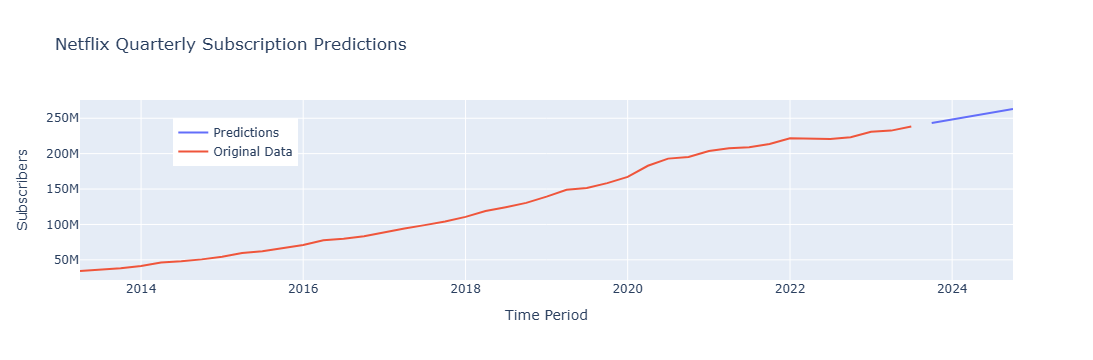

In [35]:
# Create a DataFrame with the original data and predictions
forecast = pd.DataFrame({'Original': time_series, 'Predictions': predictions})

# Plot the original data and predictions
fig = go.Figure()

fig.add_trace(go.Scatter(x=forecast.index, y=forecast['Predictions'],
                         mode='lines', name='Predictions'))

fig.add_trace(go.Scatter(x=forecast.index, y=forecast['Original'],
                         mode='lines', name='Original Data'))

fig.update_layout(title='Netflix Quarterly Subscription Predictions',
                  xaxis_title='Time Period',
                  yaxis_title='Subscribers',
                  legend=dict(x=0.1, y=0.9),
                  showlegend=True)

fig.show()

The ARIMA model forecasts that Netflix's subscriber base will maintain its steady upward trend through 2024, seamlessly continuing historical growth and surpassing 250 million subscribers.